# Step 1 - Scheduling

In [1]:
import matplotlib.pyplot as plt
import torch
from ddpm import Schedule, get_dataset

In [2]:
schedule = Schedule()

for t in [0, 100, 500, 999]:
    print(t, schedule.alpha_bars[t].item())


0 0.9998999834060669
100 0.8951413631439209
500 0.07779665291309357
999 4.035830352222547e-05


In [3]:
train_ds = get_dataset(root="../data")

print(f"size of data: {len(train_ds)}")
print(f"shape of images: {train_ds[0][0].shape}")
print("\n")

img, label = train_ds[0]
print(f"label of first image: {label}")
print(f"max value of first image: {img.max()}")
print(f"min value of first image: {img.min()}")

size of data: 60000
shape of images: torch.Size([1, 32, 32])


label of first image: 5
max value of first image: 1.0
min value of first image: -1.0


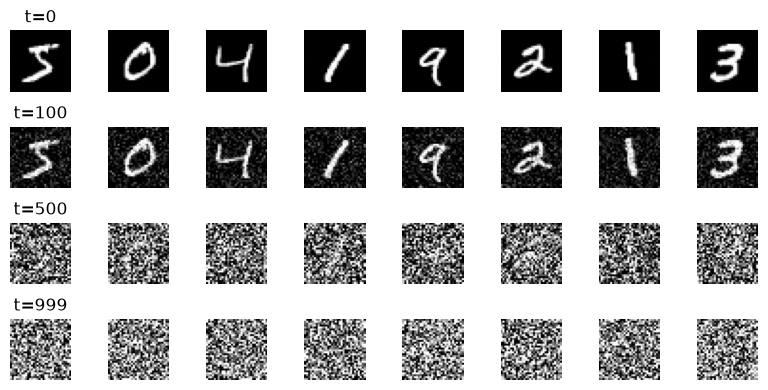

In [4]:
# Let's get the first 8 images for example
# Note that the train_ds holds tuples as (image, label), so we collect the first element of the tuples
imgs = [train_ds[i][0] for i in range(8)]
x_0 = torch.stack(imgs)

fig, axes = plt.subplots(4, 8, figsize=(8, 4))

timesteps = [0, 100, 500, 999]

for r, tv in enumerate(timesteps):
    t = torch.full((8,), tv)
    x_t, _ = schedule.q_sample(x_0, t)

    for c in range(8):
        img = x_t[c].squeeze()
        img = (img + 1) / 2
        axes[r][c].imshow(img , cmap="gray", vmin=0, vmax=1)
        axes[r][c].axis("off")

    axes[r][0].set_title(f"t={tv}")

fig.tight_layout()
plt.show()
